# Sfera di Bloch

## Raodmap

1. Import di plot_bloch_vector
2. Costruire "a mano" il vettore. di Bloch per uno stato noto e plottarlo
3. Costruire uno stato con il gate $U(\theta,\varphi,\lambda)$ e passarlo a plot_bloch_vector tramite lo Statevector
4. Confrontare due stati con la stessa $\theta$ ma $\varphi$ diverso (fase relativa - il vettore si sposta)
5. Confrontare due stati identici a meno di fase glocale (il vettore non si sposta)

## 1

In [25]:
from qiskit.visualization import plot_bloch_multivector

## 2

Scriviamo il vettore che vogliamo plottare esplicitamente.

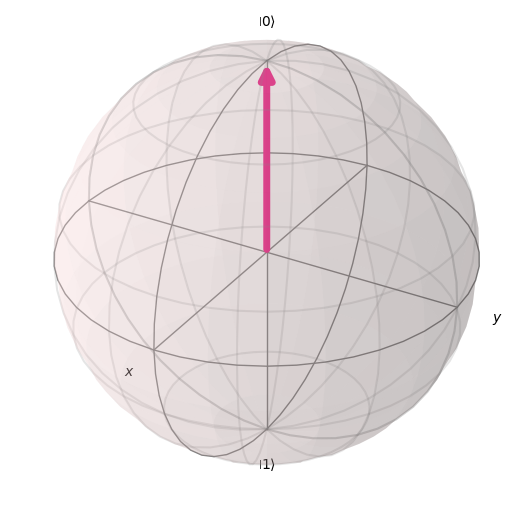

In [ ]:
plot_bloch_vector([0,0,1]) # utilizzo vector e non multivector perchè gli sto dando io il vettore, in ogni altro caso uso multivector

## 3.

Costruiamo un circuito con il gate $U(\theta,\varphi,\lambda)$ ed estraiamo lostato quantistico risultante. Sfruttiamo due strumenti:
1. QuantumCircuit : per la costruzione vera e propria del circuito
2. Statevector : per leggere lo stato senza dover misurare

In [27]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

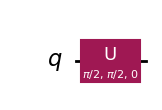

In [28]:
import numpy as np # ci è utile per determinate costanti e funzioni matematiche

qc = QuantumCircuit(1) # definiamo un circuito con 1 qubit
qc.u(np.pi/2, np.pi/2, 0, 0) # definiamo il gate quantistico U: i primi tre parametri sono le variabili relative al gate (\theta,\phi,\lambda) , il quarto parametro è l'indice del qubit di qc a cui viene applicato il gate

qc.draw('mpl')

Statevector([7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j],
            dims=(2,))


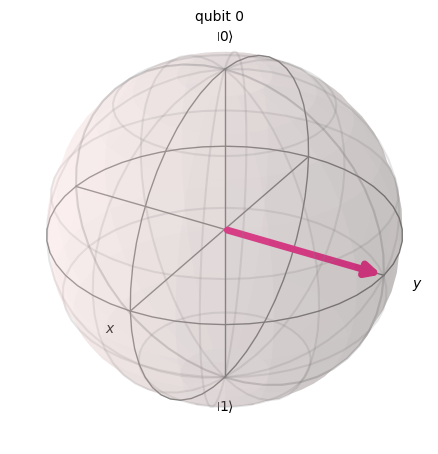

In [29]:
state = Statevector.from_instruction(qc) # deifniamo la variabile state che sarà una variabile analitica a cui sono assegnati i valori come da istruzioni in qc ( from_instruction(qc) )
print(state) # in questo modo posso vedere le ampiezze \alpha e \beta

plot_bloch_multivector(state)

## 4.

Verifichiamo ora l'effetto della fase relativa utilizzando un nuovo circuito

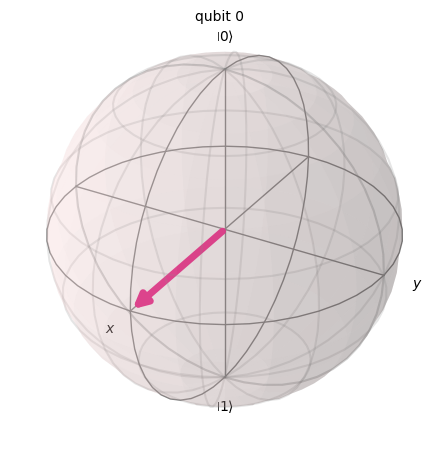

In [30]:
qc2 = QuantumCircuit(1)
qc2.u(np.pi/2, 0, 0, 0)
state2 = Statevector.from_instruction(qc2)
plot_bloch_multivector(state2)

## 5.

Verrifichiamo che una fase globale non cambia nulla di fisico: lo facciamo prendendo lo stato state2 e moltiplicandolo per un fattore di fase globale

Statevector([0.35355339+0.61237244j, 0.35355339+0.61237244j],
            dims=(2,))


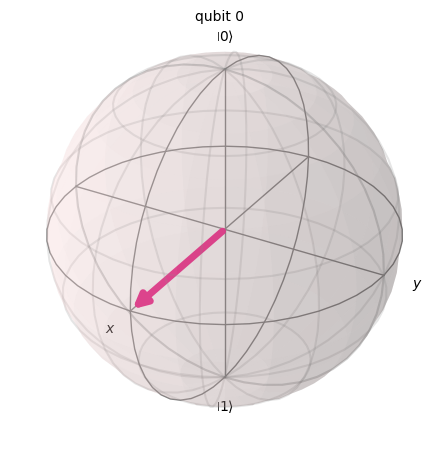

In [32]:
global_phase = np.pi/3 # definisco una fase globale
state2_global = Statevector(np.exp(1j*global_phase) * state2.data) # utilizzo state2.data (array NumPy grezzo delle ampiezze) moltiplicandolo per ottenere delle nuove ampiezze
# non usa from_instructions come in precedenza ma il costruttore diretto, gli sto dando io le istruzioni adesso

print(state2_global)
plot_bloch_multivector(state2_global)